# Netflix Data Science Project🎬


## Task 1: Data Understanding & Dataset Exploration📊


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("netflix_titles.csv")

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

### Dataset Description
The Netflix dataset contains information about movies and TV shows available on Netflix.

It includes:
- Title
- Type (Movie or TV Show)
- Director
- Cast
- Country
- Release Year
- Rating
- Duration
- Genre
- Description

The dataset contains 8807 rows and 12 columns.

# Task 2: Data Cleaning & Preprocessing🧹

In [ ]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
df['director'] = df['director'].fillna('Unknown')

In [ ]:
df['cast'] = df['cast'].fillna('Not Available')

In [ ]:
df['country'] = df['country'].fillna('Unknown')

In [ ]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [ ]:
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

### Remove rows with missing date_added

In [ ]:
df = df.dropna(subset=['date_added'])

### Rechecking Missing Values

In [ ]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### Checking Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(0)

### Formatting Date Column


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

### Checking Data Types After Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   duration      8797 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 893.4+ KB


### Conclusion
The dataset was cleaned successfully by:
- Handling missing values
- Removing duplicate rows
- Formatting date columns correctly

The dataset is now ready for Exploratory Data Analysis (EDA).

# Task 3: Exploratory Data Analysis (EDA)📈

## Distribution of Content Types

In [ ]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

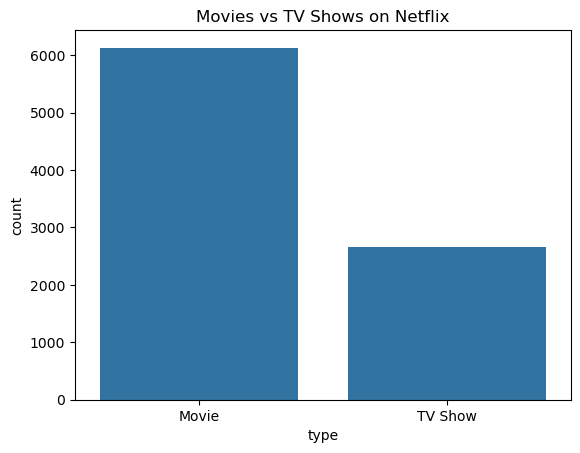

In [ ]:
sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows on Netflix')

plt.show()

## Top 10 Content Producing Countries

In [ ]:
top_countries = df['country'].value_counts().head(10)

top_countries

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

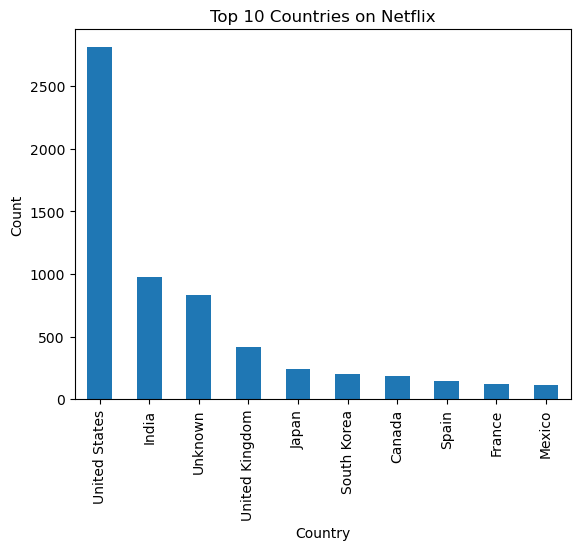

In [ ]:
top_countries.plot(kind='bar')

plt.title('Top 10 Countries on Netflix')

plt.xlabel('Country')

plt.ylabel('Count')

plt.show()

## Content Released Over the Years

In [ ]:
df['release_year'].value_counts().head()

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
Name: count, dtype: int64

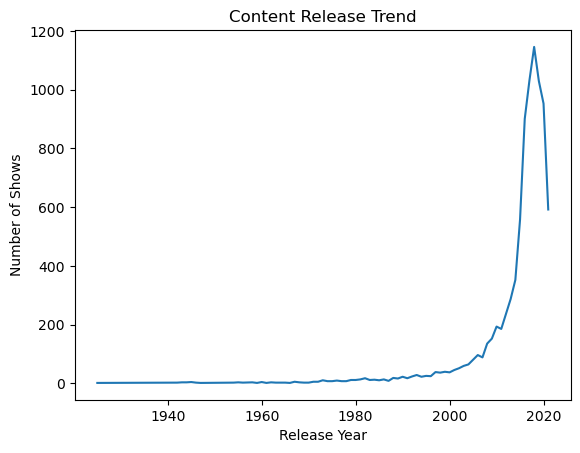

In [ ]:
df['release_year'].value_counts().sort_index().plot()

plt.title('Content Release Trend')

plt.xlabel('Release Year')

plt.ylabel('Number of Shows')

plt.show()

## Most Common Ratings

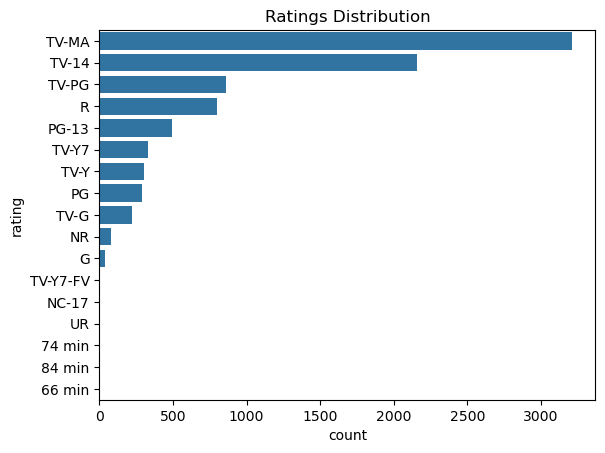

In [ ]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)

plt.title('Ratings Distribution')

plt.show()

## Most Popular Genres

In [ ]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

# Key Insights

- Movies are more common than TV Shows on Netflix.
- The United States produces the highest amount of Netflix content.
- Netflix content increased significantly after 2015.
- TV-MA is one of the most common ratings on Netflix.
- Drama and International Movies are among the most popular genres.

# Conclusion

Exploratory Data Analysis helped uncover important trends and patterns in the Netflix dataset.

The analysis showed growth in Netflix content over recent years, dominance of movie content, and the popularity of certain genres and ratings.